Image Processing

* [] Grayscale
1. biar semakin simple, karena dataset kan ga cuma 1 gambar doang (ratusan atau ribuan)
2. fokus on essentials (edges) garis/tepian
3. improve aglgoritma lebih cepet stabil dan konsisten

* [] Filtering image -> adalah memodifikasi pixels value, dengan menggunakan pixel tetangganya kiri kanan atas bawah, untuk menajamkan/blur gambar kita.
1. averaging -> semua pixels di average dan blurnya secara merata aja
2. gaussian -> ada rumus gaussian, ada formula/rumus, (masih average)
3. median -> hapus noise dengan ganti pixels pake mdeia value
4. bilateral
* [] Threshold -> convert grayscale jadi binary (compare) thAreshold

kenapa image processing dulu?
karena image itu banyak noise, dll harus dibersihin

In [ ]:
# # Install packages lengkap untuk AI/ML/CV/NLP/Biology
# !pip install torch torchvision opencv-python opencv-contrib-python transformers
# !pip install spacy gensim textblob biopython scikit-bio 
# # !pip install xgboost lightgbm albumentations ultralytics mediapipe
# !pip install gradio sentence-transformers datasets accelerate

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached transformers-5.2.0-py3-none-any.whl.metadata (32 kB)
  Using cached huggingface_hub-1.4.1-py3-none-any.whl.metadata (13 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached typer_slim-0.24.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached hf_xet-1.2.0-cp37-abi3-win_amd64.whl.metadata (5.0 kB)
  Using cached typer-0.24.0-py3-none-any.whl.metadata (16 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
   ---------------------------------------- 0.0/46.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/46.5 MB 6.7 MB/s eta 0

   ---------------------------------------- 0.0/24.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.2 MB ? eta -:--:--
   - -------------------------------------- 1.0/24.2 MB 3.6 MB/s eta 0:00:07
   --- ------------------------------------ 2.4/24.2 MB 4.4 MB/s eta 0:00:06
   ----- ---------------------------------- 3.1/24.2 MB 4.2 MB/s eta 0:00:06
   ------ --------------------------------- 3.7/24.2 MB 3.8 MB/s eta 0:00:06
   ------ --------------------------------- 3.7/24.2 MB 3.8 MB/s eta 0:00:06
   ------ --------------------------------- 3.7/24.2 MB 3.8 MB/s eta 0:00:06
   -------- ------------------------------- 5.0/24.2 MB 3.1 MB/s eta 0:00:07
   -------- ------------------------------- 5.2/24.2 MB 3.1 MB/s eta 0:00:07
   -------- ------------------------------- 5.2/24.2 MB 3.1 MB/s eta 0:00:07
   --------- ------------------------------ 6.0/24.2 MB 2.7 MB/s eta 0:00:07
   ----------- ---------------------------- 6.8/24.2 MB 2.8 MB/s eta 0:00:07
   ----------

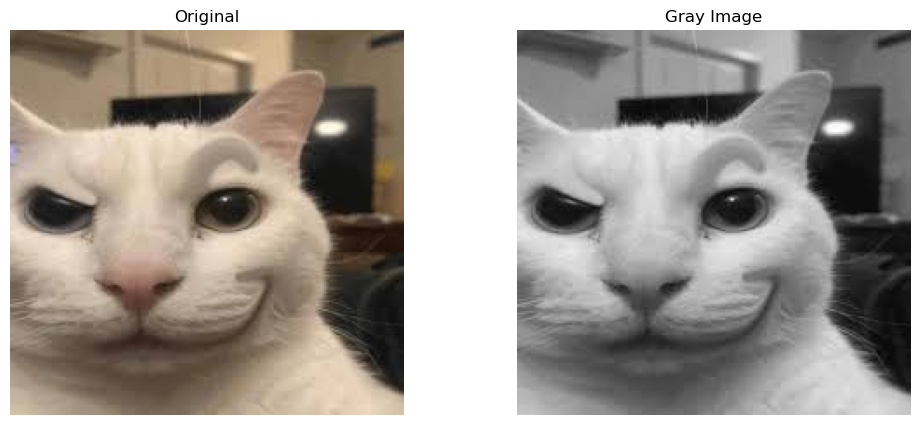

In [4]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('catts.jpeg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Convert BGR to RGB for matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display images using matplotlib (works in notebooks)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap='gray')
plt.title('Gray Image')
plt.axis('off')

plt.show()

In [ ]:
# Filtering

img = cv2.imread('catts.jpeg')

# 4 types of filtering : blur, GaussianBlur, medianBlur, bilateralFilter
blur = cv2.blur(img, (5,5)) # (5,5) -> kernel size
GaussianBlur = cv2.GaussianBlur(img, (5,5), 0) # 0 -> sigmaX
# for gaussian formula, let python do the calculation :)
medianBlur = cv2.medianBlur(img, 5) # 5 -> 5 x 5 sama aja kaya (5,5)
# diatas. Harus ganjil valuenya supaya bisa dapat median value
bilateralFilter = cv2.bilateralFilter(img, 0, 75, 75)
# d -> diameter => kernel size
# sigmaColor -> seberapa cepat pengaruh warna menurun
# biasanya low value aja 10-30 supaya warna yang mirip aja yang dhitung
# sigmaSpace -> seberapa cepat pengaruh jarak menurun
# biasanya kalau mau lokal di value 1-20, kalau 50 keatas ibaratnya jarak yang jauhpun pixelnya jadi perhitungan ke kalkulasi

# Display filtered images
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.imshow(blur)
plt.title('Blur')
plt.axis('off')
plt.subplot(2, 2, 2)
plt.imshow(GaussianBlur)
plt.title('Gaussian Blur')
plt.axis('off')
plt.subplot(2, 2, 3)
plt.imshow(medianBlur)
plt.title('Median Blur')
plt.axis('off')
plt.subplot(2, 2, 4)
plt.imshow(bilateralFilter)
plt.title('Bilateral Filter')
plt.axis('off')
plt.show()

Otsu's threshold value: 124.0


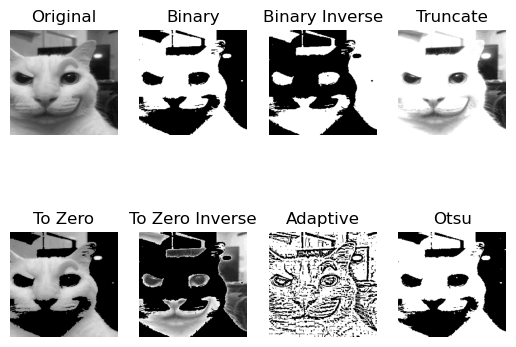

In [ ]:
# Thresholding

img = cv2.imread('catts.jpeg', cv2.IMREAD_GRAYSCALE)

# (src Img, thresholdValue, maxVal, type)
# maxVal = nilai yang diberikan kalau kondisi terpenuhi
_, th1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
_, th2 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
_, th3 = cv2.threshold(img, 127, 255, cv2.THRESH_TRUNC)
_, th4 = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO)
_, th5 = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO_INV)
th6 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 9, 2)
# (srcImg, maxVal, adaptiveMethod, typeThreshold, blockSize, C)
# blockSize -> kernel size, harus ganjil = 9 -> 9 x 9
# C = threshold = adaptiveMethodReslut - C

ret_otsu, th7 = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) 
# thres = 0 karena otsu yang kalkulasi secara otomatis
print("Otsu's threshold value:", ret_otsu)

#display thresholded images
result_img = [img, th1, th2, th3, th4, th5, th6, th7]
result_title = [
    'Original', 
    'Binary', 
    'Binary Inverse', 
    'Truncate', 
    'To Zero', 
    'To Zero Inverse', 
    'Adaptive', 
    'Otsu']

for idx, (img, title) in enumerate(zip(result_img, result_title)):
    plt.subplot(2, 4, idx + 1)
    plt.imshow(img, 'gray')
    plt.title(title)
    plt.axis('off')

plt.show()

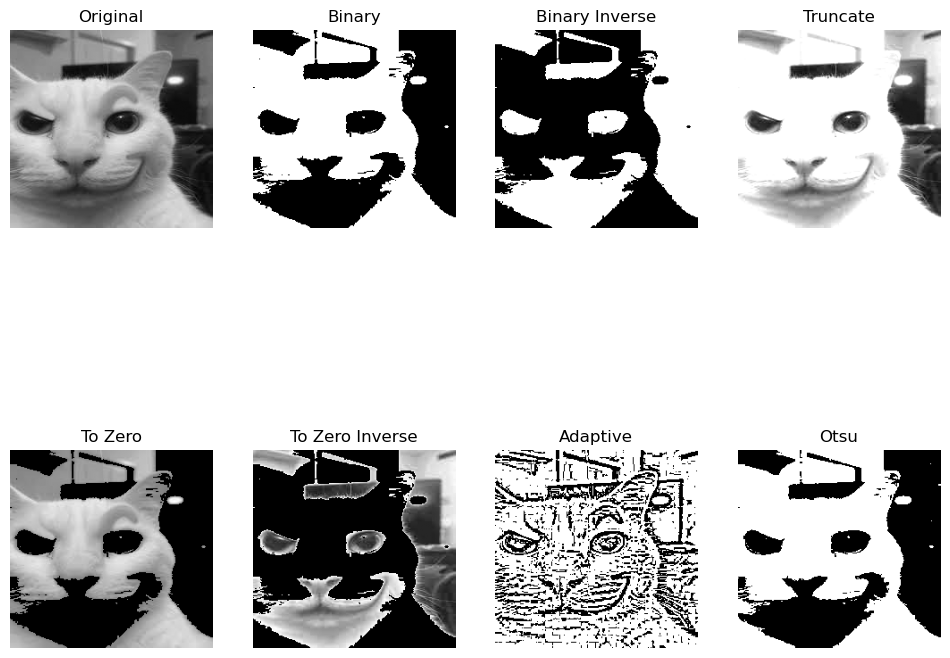

In [27]:
plt.figure(figsize=(12, 10))
for idx, (img, title) in enumerate(zip(result_img, result_title)):
    plt.subplot(2, 4, idx + 1)
    plt.imshow(img, 'gray')
    plt.title(title)
    plt.axis('off')

plt.show()